# **N1 Health: Take-Home Data Challenge**
## Analysis

N1 Health’s client, a national Medicare Advantage plan, is seeking to understand how best to use its resources to address food access challenges in its membership. N1 Health has been tasked with presenting a short analysis (~5-10 minutes) of publicly available data to the Chief Medical Officer to answer this question.

**Core Objectives**
1. Where should we deploy a food access program?
2. How many people will be included? How many might be successfully engaged?
3. Which subgroup of the population might benefit the most from the program?
4. What is the projected impact of this program?

## Part 0: Data, Definitions, EDA

In [4]:
import sqlite3
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'challenge.db').exists():
    ROOT = ROOT.parent

DB_PATH = ROOT / 'challenge.db'
assert DB_PATH.exists(), f'Missing database: {DB_PATH}'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 125, 'axes.titleweight': 'bold', 'font.size': 10})

# Helper Functions
def run_sql(sql):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn)

def show_sql(sql):
    display(Markdown('```sql\n' + textwrap.dedent(sql).strip() + '\n```'))

def percent(x, _):
    return f'{x:.0f}%'

def number(x, _):
    return f'{x/1_000_000:.1f}M' if x >= 1_000_000 else f'{x/1_000:.0f}k'


### 0.1 Datasets
- **Food Environment Atlas**: county-level data. We use 2015 fields, which is the closest supplied period to the 2016-17 500 Cities health estimates, and focus primarily on the Senior demographic subgroup.
- **500 Cities**: census tract-level data. We focus primarily on diagnosed diabetes, high cholesterol, and obesity prevalence among adults aged >=18 years across tracts within surveyed cities.

### 0.2 Definitions
**Food Environment Atlas**

In [117]:
VARIABLES_SQL = '''
SELECT "Variable Code" AS variable_code,
       "Variable Name" AS variable_name,
       "Subcategory Name" AS subcategory_name,
       Units AS units
FROM variable_list
WHERE "Variable Code" IN (
    'LACCESS_POP15',
    'PCT_LACCESS_POP15',
    'LACCESS_LOWI15',
    'PCT_LACCESS_LOWI15',
    'LACCESS_HHNV15',
    'PCT_LACCESS_HHNV15',
    'LACCESS_SNAP15',
    'PCT_LACCESS_SNAP15',
    'LACCESS_SENIORS15',
    'PCT_LACCESS_SENIORS15'
);
'''
variable_definitions = run_sql(VARIABLES_SQL)
display(variable_definitions)

,variable_code,variable_name,subcategory_name,units
0,LACCESS_POP15,"Population, low access to store, 2015",Overall,Count
1,PCT_LACCESS_POP15,"Population, low access to store (%), 2015",Overall,Percent
2,LACCESS_LOWI15,"Low income & low access to store, 2015",Household Resources,Count
3,PCT_LACCESS_LOWI15,"Low income & low access to store (%), 2015",Household Resources,Percent
4,LACCESS_HHNV15,"Households, no car & low access to store, 2015",Household Resources,Count
5,PCT_LACCESS_HHNV15,"Households, no car & low access to store (%), ...",Household Resources,Percent
6,LACCESS_SNAP15,"SNAP households, low access to store, 2015",Household Resources,Count
7,PCT_LACCESS_SNAP15,"SNAP households, low access to store (%), 2015",Household Resources,Percent
8,LACCESS_SENIORS15,"Seniors, low access to store, 2015",Demographics,Count
9,PCT_LACCESS_SENIORS15,"Seniors, low access to store (%), 2015",Demographics,Percent


**500 Cities**

In [94]:
VARIABLES_500_SQL = '''
SELECT
    name as variable_name,
    description,
    dataTypeName as data_type
FROM variables_500
WHERE name IN (
    'StateAbbr',
    'PlaceName',
    'TractFIPS',
    'Population2010',
    'DIABETES_CrudePrev',
    'HIGHCHOL_CrudePrev',
    'OBESITY_CrudePrev'
);
'''
var_def_500 = run_sql(VARIABLES_500_SQL)
display(var_def_500)

,variable_name,description,data_type
0,StateAbbr,State abbreviation,text
1,PlaceName,City name,text
2,TractFIPS,Tract FIPS code,text
3,Population2010,2010 Census population count,number
4,DIABETES_CrudePrev,Model-based estimate for crude prevalence of d...,number
5,HIGHCHOL_CrudePrev,Model-based estimate for crude prevalence of h...,number
6,OBESITY_CrudePrev,Model-based estimate for crude prevalence of o...,number


### 0.3 EDA

Based on our initial EDA, Texas contains the highest population of residents with low income & low access to stores. This statewide figure provides a starting base to magnify our analyses: among the city counties surveyed in the 500 Cities dataset, Texas contains the second highest number of seniors (65+) with low access to stores. This indicates a strong candidate for a food access program.

In [116]:
STATE_LACCESS_LOWI15_SQL = '''
SELECT
    State AS state,
    SUM(Value) AS total_laccess_lowi15
FROM access_csv_2025
WHERE Variable_Code = "LACCESS_LOWI15"
GROUP BY State
ORDER BY total_laccess_lowi15 DESC
LIMIT 10;
'''
state_laccess_lowi15_totals = run_sql(STATE_LACCESS_LOWI15_SQL)
state_laccess_lowi15_totals.round({'total_laccess_lowi15': 0})

,state,total_laccess_lowi15
0,TX,2403438.0
1,FL,1577260.0
2,CA,1338108.0
3,GA,1044083.0
4,OH,839217.0
5,NC,779642.0
6,MI,657247.0
7,TN,613114.0
8,IL,605044.0
9,PA,597683.0


In [6]:
LACCESS_SENIORS_500_SQL = '''
WITH city_counties AS (                                                
    SELECT DISTINCT
        printf('%05d', CAST(TractFIPS / 1000000 AS INTEGER)) AS geoID
    FROM five_hundred_cities
)
SELECT
    a.State AS state,
    SUM(CAST(a.Value AS REAL)) AS laccess_seniors_in_500_cities
FROM access_csv_2025 AS a
JOIN city_counties AS c
    ON a.FIPS = c.geoID
WHERE a.Variable_Code = 'LACCESS_SENIORS15'
  AND a.Value NOT IN ('', '-9999', '-8888')
GROUP BY State
ORDER BY laccess_seniors_in_500_cities DESC
LIMIT 10;
'''
laccess_seniors_500 = run_sql(LACCESS_SENIORS_500_SQL)
laccess_seniors_500.round({'laccess_seniors_in_500_cities': 0})

,state,laccess_seniors_in_500_cities
0,CA,725378.0
1,TX,616367.0
2,FL,540414.0
3,MA,272693.0
4,OH,249517.0
5,MI,227051.0
6,IL,216286.0
7,NC,204741.0
8,AZ,196600.0
9,WA,176372.0


## Part 1: Where to Deploy & Affected Population Subgroups

### 1.1 State-level Analysis
Based on the analysis below, Texas emerges as a strong candidate for a food-access program with over 616k seniors with low-access to stores, which accounts for an estimated 33.8% of the total senior population in Texas.

In [121]:
STATE_RANKING_SQL = '''
-- CTE 1: We only need 3 columns from the FEA table. We also need to filter out blank fields and negatives.
WITH food AS (
    SELECT
        FIPS,
        State,
        County,
        -- We use MAX() here because each county should have one relevant value
        -- after filtering to this variable code.
        MAX(
            CASE
                WHEN Variable_Code = 'LACCESS_SENIORS15'
                AND Value NOT IN ('', '-9999', '-8888')
                THEN CAST(Value AS REAL)
            END
        ) AS low_access_seniors,
        MAX(
            CASE
                WHEN Variable_Code = 'PCT_LACCESS_SENIORS15'
                AND Value NOT IN ('', '-9999', '-8888')
                THEN CAST(Value AS REAL)
            END
        ) AS senior_low_access_pct,
        MAX(
            CASE
                WHEN Variable_Code = 'PCT_LACCESS_LOWI15'
                AND Value NOT IN ('', '-9999', '-8888')
                THEN CAST(Value AS REAL)
            END
        ) AS low_income_low_access_pct
    FROM access_csv_2025
    GROUP BY FIPS, State, County
),

-- CTE 2: Find counties that are represented in the 500 Cities data.
-- We use the TractFIPS codes, which begins with the five-digit county FIPS code, to join tables.
city_counties AS (
    SELECT DISTINCT
        -- TractFIPS takes the form: SSCCC TTTTTT
        -- where SS = 2-digit state FIPS
        -- and CCC = 3-digit county FIPS
        -- Divide by 1000000 to obtain the county FIPS
        printf('%05d', CAST("TractFIPS" / 1000000 AS INTEGER)) AS FIPS
    FROM five_hundred_cities
),

-- CTE 3: We aggregate matched county data to the state level.
state_summary AS (
    SELECT
        f.State,
        SUM(f.low_access_seniors) AS low_access_seniors,
        -- Calculate the implied senior population in each county:
        -- low-access seniors = all seniors * (low-access percentage / 100)
        -- therefore, all seniors = (low-access seniors / low-access percentage) * 100
        -- We can then calculate the state-level, population-weighted percentage
        -- of seniors with low food-store access:
        -- 100.0 * SUM(f.low_access_seniors) / SUM(implied total senior population)
        100.0 * SUM(f.low_access_seniors) /
            SUM(
                CASE
                    WHEN f.senior_low_access_pct > 0
                    THEN f.low_access_seniors
                         / f.senior_low_access_pct
                         * 100.0
                END
            ) AS implied_senior_low_access_pct
    FROM food AS f
    JOIN city_counties AS c
        ON c.FIPS = f.FIPS
    WHERE f.low_access_seniors >= 0
      AND f.senior_low_access_pct >= 0
    GROUP BY f.State
)

-- Main query: return the top 10 states with the largest number of low-access
-- seniors among counties that overlap the 500 Cities dataset.
SELECT
    State,
    low_access_seniors,
    implied_senior_low_access_pct
FROM state_summary
ORDER BY low_access_seniors DESC
LIMIT 10;
'''
show_sql(STATE_RANKING_SQL)
state_rank = run_sql(STATE_RANKING_SQL)
state_rank.round({'low_access_seniors': 0, 'implied_senior_low_access_pct': 1})

```sql
-- CTE 1: We only need 3 columns from the FEA table. We also need to filter out blank fields and negatives.
WITH food AS (
    SELECT
        FIPS,
        State,
        County,
        -- We use MAX() here because each county should have one relevant value
        -- after filtering to this variable code.
        MAX(
            CASE
                WHEN Variable_Code = 'LACCESS_SENIORS15'
                AND Value NOT IN ('', '-9999', '-8888')
                THEN CAST(Value AS REAL)
            END
        ) AS low_access_seniors,
        MAX(
            CASE
                WHEN Variable_Code = 'PCT_LACCESS_SENIORS15'
                AND Value NOT IN ('', '-9999', '-8888')
                THEN CAST(Value AS REAL)
            END
        ) AS senior_low_access_pct,
        MAX(
            CASE
                WHEN Variable_Code = 'PCT_LACCESS_LOWI15'
                AND Value NOT IN ('', '-9999', '-8888')
                THEN CAST(Value AS REAL)
            END
        ) AS low_income_low_access_pct
    FROM access_csv_2025
    GROUP BY FIPS, State, County
),

-- CTE 2: Find counties that are represented in the 500 Cities data.
-- We use the TractFIPS codes, which begins with the five-digit county FIPS code, to join tables.
city_counties AS (
    SELECT DISTINCT
        -- TractFIPS takes the form: SSCCC TTTTTT
        -- where SS = 2-digit state FIPS
        -- and CCC = 3-digit county FIPS
        -- Divide by 1000000 to obtain the county FIPS
        printf('%05d', CAST("TractFIPS" / 1000000 AS INTEGER)) AS FIPS
    FROM five_hundred_cities
),

-- CTE 3: We aggregate matched county data to the state level.
state_summary AS (
    SELECT
        f.State,
        SUM(f.low_access_seniors) AS low_access_seniors,
        -- Calculate the implied senior population in each county:
        -- low-access seniors = all seniors * (low-access percentage / 100)
        -- therefore, all seniors = (low-access seniors / low-access percentage) * 100
        -- We can then calculate the state-level, population-weighted percentage
        -- of seniors with low food-store access:
        -- 100.0 * SUM(f.low_access_seniors) / SUM(implied total senior population)
        100.0 * SUM(f.low_access_seniors) /
            SUM(
                CASE
                    WHEN f.senior_low_access_pct > 0
                    THEN f.low_access_seniors
                         / f.senior_low_access_pct
                         * 100.0
                END
            ) AS implied_senior_low_access_pct
    FROM food AS f
    JOIN city_counties AS c
        ON c.FIPS = f.FIPS
    WHERE f.low_access_seniors >= 0
      AND f.senior_low_access_pct >= 0
    GROUP BY f.State
)

-- Main query: return the top 10 states with the largest number of low-access
-- seniors among counties that overlap the 500 Cities dataset.
SELECT
    State,
    low_access_seniors,
    implied_senior_low_access_pct
FROM state_summary
ORDER BY low_access_seniors DESC
LIMIT 10;
```

,State,low_access_seniors,implied_senior_low_access_pct
0,CA,725378.0,18.7
1,TX,616367.0,33.8
2,FL,540414.0,26.6
3,MA,272693.0,34.5
4,OH,249517.0,32.1
5,MI,227051.0,30.5
6,IL,216286.0,20.2
7,NC,204741.0,41.1
8,AZ,196600.0,30.5
9,WA,176372.0,31.7


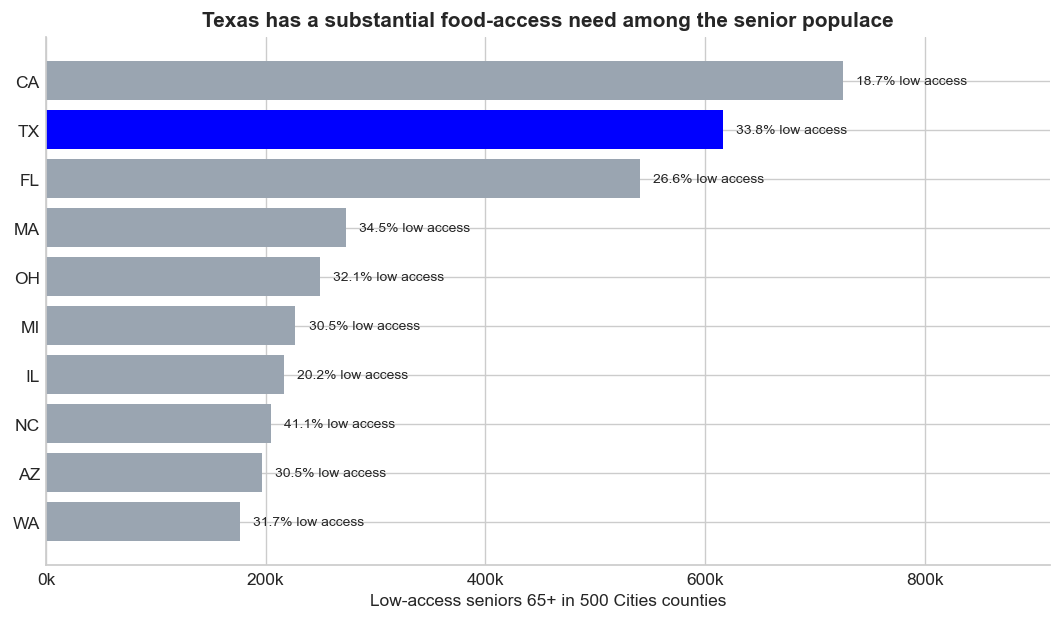

In [167]:
plot_states = state_rank.sort_values('low_access_seniors').tail(12).copy()
colors = ['#9AA5B1'] * len(plot_states)
colors[list(plot_states['State']).index('TX')] = '#0000FF'
fig, ax = plt.subplots(figsize=(8.6, 5.4))
bars = ax.barh(plot_states['State'], plot_states['low_access_seniors'], color=colors)
ax.xaxis.set_major_formatter(FuncFormatter(number))
ax.set_xlabel('Low-access seniors 65+ in 500 Cities counties')
ax.set_title('Texas has a substantial food-access need among the senior populace')
for bar, row in zip(bars, plot_states.itertuples()):
    ax.text(bar.get_width() + 12000, bar.get_y() + bar.get_height()/2,
            f'{row.implied_senior_low_access_pct:.1f}% low access', va='center', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, plot_states['low_access_seniors'].max() * 1.26)
plt.tight_layout(rect=(0, .06, 1, 1))
plt.show()

### 1.2 County-level analysis
Within Texas, where is there a demonstrated need for food-access programs and county-level subtrates where underlying health burdens are highly present? Hidalgo, Cameron, and McLennan counties point to areas with high health burdens such as obesity, high cholestrol, and diabetes among the senior populace.

In [141]:
TEXAS_COUNTY_SQL = '''
WITH food AS (
    SELECT FIPS, State, County,
           MAX(CASE WHEN Variable_Code = 'LACCESS_SENIORS15'
                    AND Value NOT IN ('', '-9999', '-8888') THEN CAST(Value AS REAL) END) AS low_access_seniors,
           MAX(CASE WHEN Variable_Code = 'PCT_LACCESS_SENIORS15'
                    AND Value NOT IN ('', '-9999', '-8888') THEN CAST(Value AS REAL) END) AS senior_low_access_pct,
           MAX(CASE WHEN Variable_Code = 'PCT_LACCESS_LOWI15'
                    AND Value NOT IN ('', '-9999', '-8888') THEN CAST(Value AS REAL) END) AS low_income_low_access_pct,
           MAX(CASE WHEN Variable_Code = 'PCT_LACCESS_POP15'
                    AND Value NOT IN ('', '-9999', '-8888') THEN CAST(Value AS REAL) END) AS overall_low_access_pct
    FROM access_csv_2025
    GROUP BY FIPS, State, County
), tract_summary AS (
    SELECT printf('%05d', CAST("TractFIPS" / 1000000 AS INTEGER)) AS FIPS,
           StateAbbr AS State,
           SUM("Population2010" * "DIABETES_CrudePrev") / SUM("Population2010") AS diabetes_pct,
           SUM("Population2010" * "OBESITY_CrudePrev") / SUM("Population2010") AS obesity_pct,
           SUM("Population2010" * "HIGHCHOL_CrudePrev") / SUM("Population2010") AS high_cholestrol_pct
    FROM five_hundred_cities
    GROUP BY FIPS, State
)
SELECT f.County, f.low_access_seniors,
       f.low_income_low_access_pct,
       t.diabetes_pct, t.obesity_pct, t.high_cholestrol_pct
FROM food f
JOIN tract_summary t ON t.FIPS = f.FIPS AND t.State = f.State
WHERE f.State = 'TX'
  AND f.low_access_seniors >= 0
  AND f.low_income_low_access_pct >= 0
ORDER BY f.low_income_low_access_pct DESC, f.low_access_seniors DESC;
'''
show_sql(TEXAS_COUNTY_SQL)
texas_counties = run_sql(TEXAS_COUNTY_SQL)
texas_counties.head(12).round(1)

```sql
WITH food AS (
    SELECT FIPS, State, County,
           MAX(CASE WHEN Variable_Code = 'LACCESS_SENIORS15'
                    AND Value NOT IN ('', '-9999', '-8888') THEN CAST(Value AS REAL) END) AS low_access_seniors,
           MAX(CASE WHEN Variable_Code = 'PCT_LACCESS_SENIORS15'
                    AND Value NOT IN ('', '-9999', '-8888') THEN CAST(Value AS REAL) END) AS senior_low_access_pct,
           MAX(CASE WHEN Variable_Code = 'PCT_LACCESS_LOWI15'
                    AND Value NOT IN ('', '-9999', '-8888') THEN CAST(Value AS REAL) END) AS low_income_low_access_pct,
           MAX(CASE WHEN Variable_Code = 'PCT_LACCESS_POP15'
                    AND Value NOT IN ('', '-9999', '-8888') THEN CAST(Value AS REAL) END) AS overall_low_access_pct
    FROM access_csv_2025
    GROUP BY FIPS, State, County
), tract_summary AS (
    SELECT printf('%05d', CAST("TractFIPS" / 1000000 AS INTEGER)) AS FIPS,
           StateAbbr AS State,
           SUM("Population2010" * "DIABETES_CrudePrev") / SUM("Population2010") AS diabetes_pct,
           SUM("Population2010" * "OBESITY_CrudePrev") / SUM("Population2010") AS obesity_pct,
           SUM("Population2010" * "HIGHCHOL_CrudePrev") / SUM("Population2010") AS high_cholestrol_pct
    FROM five_hundred_cities
    GROUP BY FIPS, State
)
SELECT f.County, f.low_access_seniors,
       f.low_income_low_access_pct,
       t.diabetes_pct, t.obesity_pct, t.high_cholestrol_pct
FROM food f
JOIN tract_summary t ON t.FIPS = f.FIPS AND t.State = f.State
WHERE f.State = 'TX'
  AND f.low_access_seniors >= 0
  AND f.low_income_low_access_pct >= 0
ORDER BY f.low_income_low_access_pct DESC, f.low_access_seniors DESC;
```

,County,low_access_seniors,low_income_low_access_pct,diabetes_pct,obesity_pct,high_cholestrol_pct
0,Hidalgo,27747.5,24.0,15.2,42.2,31.5
1,McLennan,18514.7,20.5,12.5,37.2,32.3
2,Cameron,20960.4,19.8,17.3,41.0,34.5
3,Tom Green,7458.1,17.5,11.5,34.5,33.4
4,Brazos,6221.1,15.0,7.6,28.3,26.1
5,Bell,15429.3,14.8,9.6,37.1,27.0
6,Webb,4033.9,14.4,15.6,42.2,33.0
7,Taylor,7314.8,12.8,11.1,33.0,33.5
8,Bexar,61004.9,11.8,13.2,34.8,32.1
9,Wichita,6889.8,11.1,11.9,37.8,33.7


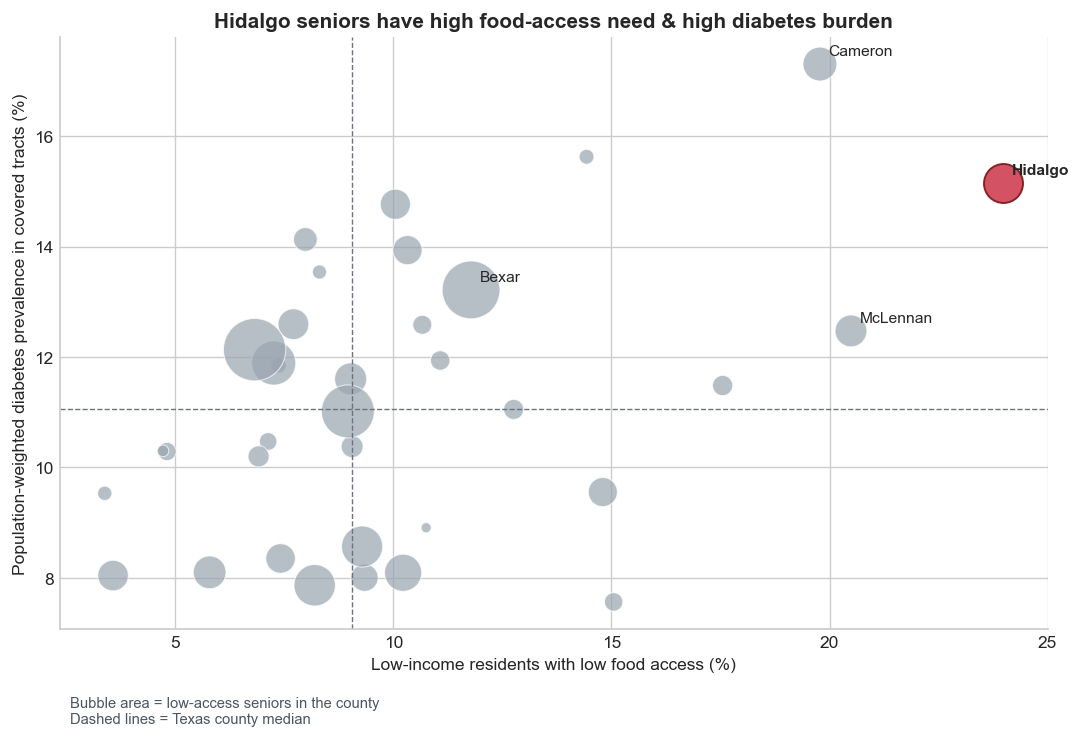

In [142]:
fig, ax = plt.subplots(figsize=(8.8, 6.0))
sizes = texas_counties['low_access_seniors'] / 55
is_hidalgo = texas_counties['County'].eq('Hidalgo')
ax.scatter(texas_counties.loc[~is_hidalgo, 'low_income_low_access_pct'],
           texas_counties.loc[~is_hidalgo, 'diabetes_pct'],
           s=sizes[~is_hidalgo], color='#9AA5B1', alpha=.72, edgecolor='white', linewidth=.6)
ax.scatter(texas_counties.loc[is_hidalgo, 'low_income_low_access_pct'],
           texas_counties.loc[is_hidalgo, 'diabetes_pct'],
           s=sizes[is_hidalgo], color='#D1495B', alpha=.95, edgecolor='#7F1D1D', linewidth=1.1, zorder=3)

for county in ['Hidalgo', 'Cameron', 'McLennan', 'Bexar']:
    row = texas_counties.loc[texas_counties['County'].eq(county)].iloc[0]
    ax.annotate(county, (row.low_income_low_access_pct, row.diabetes_pct),
                xytext=(5, 5), textcoords='offset points', fontsize=9, weight='bold' if county == 'Hidalgo' else 'normal')

ax.axvline(texas_counties['low_income_low_access_pct'].median(), color='#6B7280', lw=.8, ls='--')
ax.axhline(texas_counties['diabetes_pct'].median(), color='#6B7280', lw=.8, ls='--')
ax.set_xlabel('Low-income residents with low food access (%)')
ax.set_ylabel('Population-weighted diabetes prevalence in covered tracts (%)')
ax.set_title('Hidalgo seniors have high food-access need & high diabetes burden')
ax.text(.01, -.16, 'Bubble area = low-access seniors in the county\nDashed lines = Texas county median',
        transform=ax.transAxes, fontsize=8.5, color='#4B5563')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

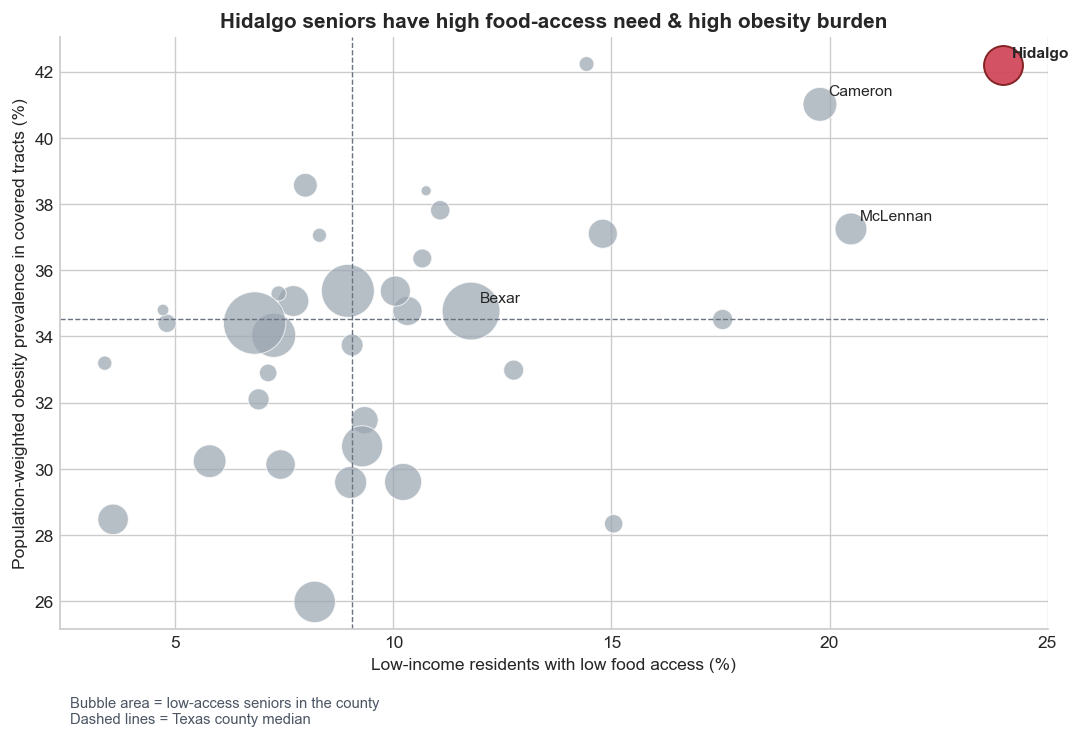

In [148]:
fig, ax = plt.subplots(figsize=(8.8, 6.0))
sizes = texas_counties['low_access_seniors'] / 55
is_hidalgo = texas_counties['County'].eq('Hidalgo')
ax.scatter(texas_counties.loc[~is_hidalgo, 'low_income_low_access_pct'],
           texas_counties.loc[~is_hidalgo, 'obesity_pct'],
           s=sizes[~is_hidalgo], color='#9AA5B1', alpha=.72, edgecolor='white', linewidth=.6)
ax.scatter(texas_counties.loc[is_hidalgo, 'low_income_low_access_pct'],
           texas_counties.loc[is_hidalgo, 'obesity_pct'],
           s=sizes[is_hidalgo], color='#D1495B', alpha=.95, edgecolor='#7F1D1D', linewidth=1.1, zorder=3)

for county in ['Hidalgo', 'Cameron', 'McLennan', 'Bexar']:
    row = texas_counties.loc[texas_counties['County'].eq(county)].iloc[0]
    ax.annotate(county, (row.low_income_low_access_pct, row.obesity_pct),
                xytext=(5, 5), textcoords='offset points', fontsize=9, weight='bold' if county == 'Hidalgo' else 'normal')

ax.axvline(texas_counties['low_income_low_access_pct'].median(), color='#6B7280', lw=.8, ls='--')
ax.axhline(texas_counties['obesity_pct'].median(), color='#6B7280', lw=.8, ls='--')
ax.set_xlabel('Low-income residents with low food access (%)')
ax.set_ylabel('Population-weighted obesity prevalence in covered tracts (%)')
ax.set_title('Hidalgo seniors have high food-access need & high obesity burden')
ax.text(.01, -.16, 'Bubble area = low-access seniors in the county\nDashed lines = Texas county median',
        transform=ax.transAxes, fontsize=8.5, color='#4B5563')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

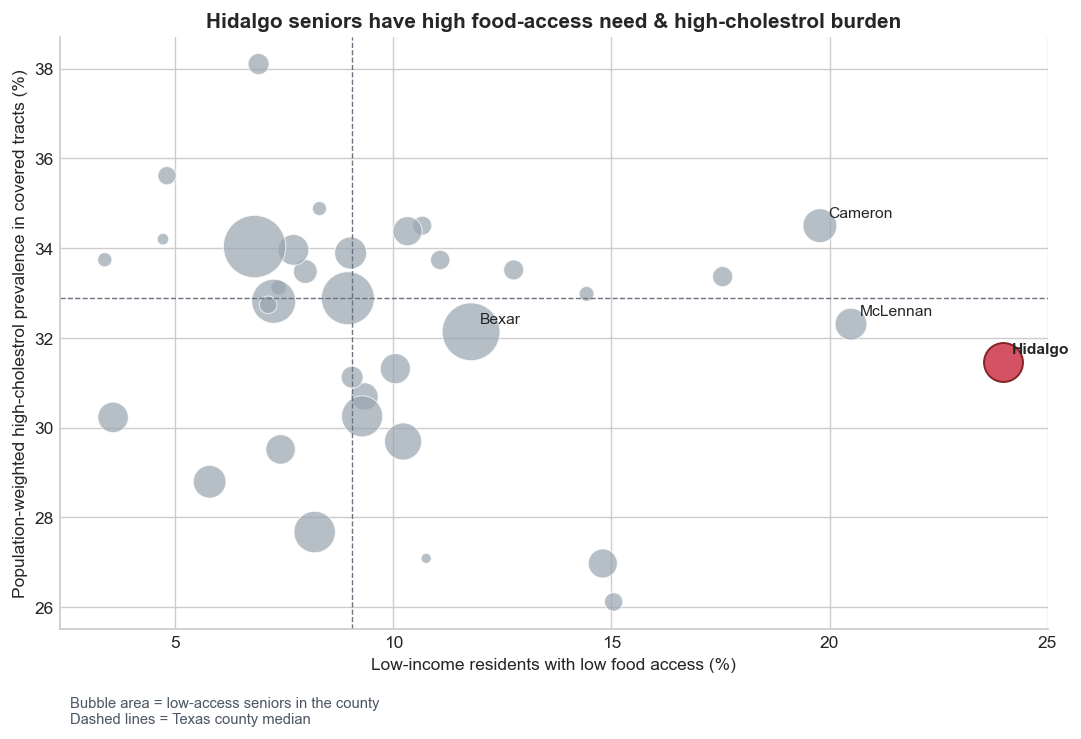

In [149]:
fig, ax = plt.subplots(figsize=(8.8, 6.0))
sizes = texas_counties['low_access_seniors'] / 55
is_hidalgo = texas_counties['County'].eq('Hidalgo')
ax.scatter(texas_counties.loc[~is_hidalgo, 'low_income_low_access_pct'],
           texas_counties.loc[~is_hidalgo, 'high_cholestrol_pct'],
           s=sizes[~is_hidalgo], color='#9AA5B1', alpha=.72, edgecolor='white', linewidth=.6)
ax.scatter(texas_counties.loc[is_hidalgo, 'low_income_low_access_pct'],
           texas_counties.loc[is_hidalgo, 'high_cholestrol_pct'],
           s=sizes[is_hidalgo], color='#D1495B', alpha=.95, edgecolor='#7F1D1D', linewidth=1.1, zorder=3)

for county in ['Hidalgo', 'Cameron', 'McLennan', 'Bexar']:
    row = texas_counties.loc[texas_counties['County'].eq(county)].iloc[0]
    ax.annotate(county, (row.low_income_low_access_pct, row.high_cholestrol_pct),
                xytext=(5, 5), textcoords='offset points', fontsize=9, weight='bold' if county == 'Hidalgo' else 'normal')

ax.axvline(texas_counties['low_income_low_access_pct'].median(), color='#6B7280', lw=.8, ls='--')
ax.axhline(texas_counties['high_cholestrol_pct'].median(), color='#6B7280', lw=.8, ls='--')
ax.set_xlabel('Low-income residents with low food access (%)')
ax.set_ylabel('Population-weighted high-cholestrol prevalence in covered tracts (%)')
ax.set_title('Hidalgo seniors have high food-access need & high-cholestrol burden')
ax.text(.01, -.16, 'Bubble area = low-access seniors in the county\nDashed lines = Texas county median',
        transform=ax.transAxes, fontsize=8.5, color='#4B5563')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 1.3 City-level analysis

A simple zoom-in to Hidalgo at the city-level show tracts with high burdens of diabetes, obesity, and high-cholestrol.

In [5]:
HIDALGO_CITY_SQL = '''
SELECT PlaceName AS city,
  COUNT(*) AS tracts,
  SUM(Population2010) AS population,
  SUM(Population2010 * DIABETES_CrudePrev) / SUM(Population2010) AS diabetes_pct,
  SUM(Population2010 * OBESITY_CrudePrev) / SUM(Population2010) AS obesity_pct,
  SUM(Population2010 * HIGHCHOL_CrudePrev) / SUM(Population2010) AS high_cholestrol_pct,
  SUM(Population2010 * DIABETES_CrudePrev / 100.0) AS estimated_adults_with_diabetes,
  SUM(Population2010 * OBESITY_CrudePrev / 100.0) AS estimated_adults_with_obesity,
  SUM(Population2010 * HIGHCHOL_CrudePrev / 100.0) AS estimated_adults_with_highchol
FROM five_hundred_cities
WHERE printf('%05d', CAST(TractFIPS / 1000000 AS INTEGER)) = '48215'
GROUP BY city
ORDER BY tracts DESC;
'''
show_sql(HIDALGO_CITY_SQL)
hidalgo_cities = run_sql(HIDALGO_CITY_SQL)
hidalgo_cities.round({'diabetes_pct': 1,
                      'obesity_pct': 1,
                      'high_cholestrol_pct': 1,
                      'estimated_adults_with_diabetes': 0,
                      'estimated_adults_with_obesity': 0,
                      'estimated_adults_with_highchol': 0
                    })

```sql
SELECT PlaceName AS city,
  COUNT(*) AS tracts,
  SUM(Population2010) AS population,
  SUM(Population2010 * DIABETES_CrudePrev) / SUM(Population2010) AS diabetes_pct,
  SUM(Population2010 * OBESITY_CrudePrev) / SUM(Population2010) AS obesity_pct,
  SUM(Population2010 * HIGHCHOL_CrudePrev) / SUM(Population2010) AS high_cholestrol_pct,
  SUM(Population2010 * DIABETES_CrudePrev / 100.0) AS estimated_adults_with_diabetes,
  SUM(Population2010 * OBESITY_CrudePrev / 100.0) AS estimated_adults_with_obesity,
  SUM(Population2010 * HIGHCHOL_CrudePrev / 100.0) AS estimated_adults_with_highchol
FROM five_hundred_cities
WHERE printf('%05d', CAST(TractFIPS / 1000000 AS INTEGER)) = '48215'
GROUP BY city
ORDER BY tracts DESC;
```

,city,tracts,population,diabetes_pct,obesity_pct,high_cholestrol_pct,estimated_adults_with_diabetes,estimated_adults_with_obesity,estimated_adults_with_highchol
0,McAllen,25,129852,15.5,41.6,32.2,20120.0,54037.0,41867.0
1,Mission,15,77050,15.0,41.5,32.0,11593.0,31998.0,24632.0
2,Edinburg,13,77100,13.5,41.6,28.9,10399.0,32084.0,22249.0
3,Pharr,9,70400,16.5,44.6,32.3,11613.0,31391.0,22741.0


## Part 2: Projected Impact

In [161]:
hidalgo = texas_counties.loc[texas_counties['County'].eq('Hidalgo')].iloc[0]
projected_seniors = int(round(hidalgo['low_access_seniors']))

scenario = pd.DataFrame({
    'Engagement rate': [0.20, 0.40, 0.60],
})
scenario['Eligible seniors'] = projected_seniors
scenario['Total impact'] = (scenario['Eligible seniors'] * scenario['Engagement rate']).round().astype(int)
scenario.assign(**{'Engagement rate': (scenario['Engagement rate'] * 100).map('{:.0f}%'.format)})

,Engagement rate,Eligible seniors,Total impact
0,20%,27747,5549
1,40%,27747,11099
2,60%,27747,16648


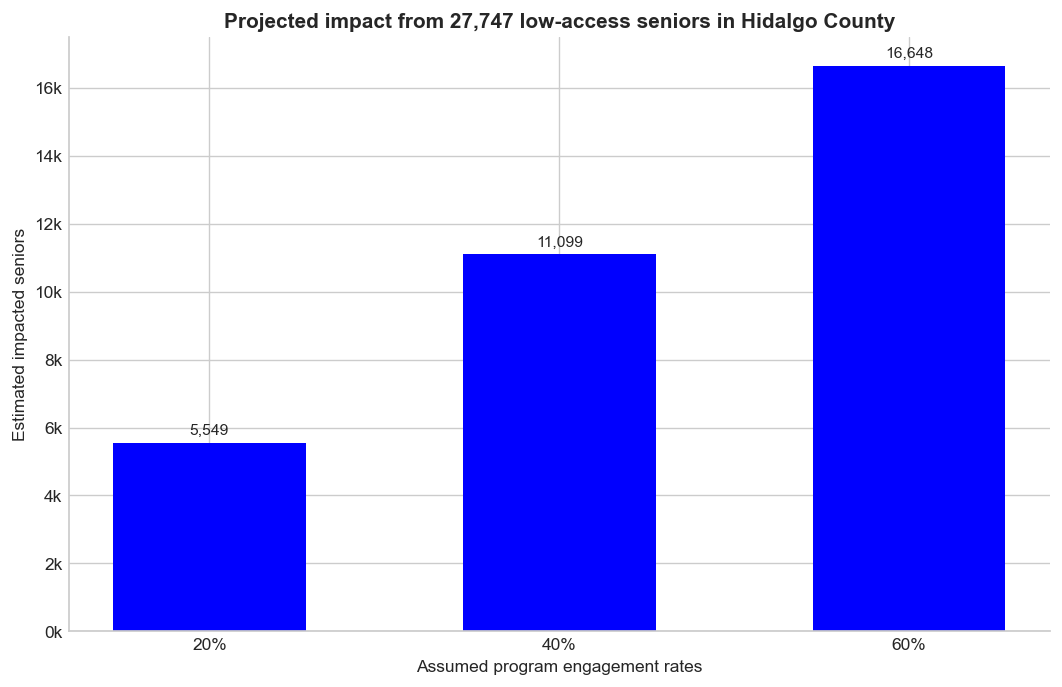

In [168]:
fig, ax = plt.subplots(figsize=(8.6, 5.6))
x = list(range(len(scenario)))
bars_enrolled = ax.bar(
    x,
    scenario['Total impact'],
    color='#0000FF',
    width=.55
)
ax.bar_label(
    bars_enrolled,
    labels=[f'{value:,.0f}' for value in bars_enrolled.datavalues],
    padding=3,
    fontsize=9
)
ax.set_xticks(
    x,
    [f'{rate:.0%}' for rate in scenario['Engagement rate']]
)
ax.yaxis.set_major_formatter(FuncFormatter(number))
ax.set_xlabel('Assumed program engagement rates')
ax.set_ylabel('Estimated impacted seniors')
ax.set_title(
    f'Projected impact from {projected_seniors:,} low-access seniors in Hidalgo County'
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Conclusion

Based on our analysis, we recommend deploying a targeted food-access program in Hidalgo County, Texas. Among Texas counties represented in the 500 Cities data, Hidalgo combines a substantial estimated low-access senior population (approximately 27,747 adults age 65 or older) with a high low-income/low-access rate of 24.0%. Its covered census tracts also show elevated health burdens, including 15.2% diabetes prevalence, 31.5% high-cholestrol prevalence, and 42.2% obesity prevalence across a population of roughly 354,000 residents among Hidalgo County tracts included in the 500 Cities dataset.